In [4]:
import numpy as np
import pandas as pd
files = [
    ("crime_and_punishment.txt", "human"),
    ("pride_and_prejudice.txt", "human"),
    ("class2_crime_and_punishment.txt", "ai"),
    ("class2_pride_and_prejudice.txt", "ai"),
    ("class3_crime_and_punishment.txt", "ai-adv"),
    ("class3_pride_and_prejudice.txt", "ai-adv"),
]

all_data = []

for file, tag in files:
    with open(f"books/{file}", "r", encoding="utf-8") as f:
        content = f.read()
        paragraphs = content.split('\n\n')
        for para in paragraphs:
            para_words = para.split()
            if len(para_words) >= 50 and len(para_words) <= 220:
                all_data.append({'text': para.strip(), 'label': tag})
                
print(f"Total paragraphs extracted: {len(all_data)}")

Total paragraphs extracted: 3252


Lexical richness

In [ ]:
from collections import Counter
from random import randrange

for file, tag in files:
    with open(f"books/{file}", "r", encoding="utf-8") as f:
        print("Stats for file:", file)
        content = f.read()
        content = content.lower()
        content = ''.join(char if char.isalpha() or char.isspace() else ' ' for char in content)

        words = content.split()
        all_word_counts = Counter(words)
        ttr = len(all_word_counts) / len(words)

        randsamp_start = randrange(len(words) - 5000)
        sample = words[randsamp_start: randsamp_start + 5000]
        sample_word_counts = Counter(sample)
        hapax = len([word for word, count in sample_word_counts.items() if count == 1])

        print("TTR:", ttr, end=" | ")
        print("Hapax legomena:", hapax)
        print()

ai_avg_ttr = 0
ai_avg_hapax = 0
ai_adv_avg_ttr = 0
ai_adv_avg_hapax = 0
human_avg_ttr = 0
human_avg_hapax = 0
for para_data in all_data:
    para_text = para_data['text'].lower()
    para_text = ''.join(char if char.isalpha() or char.isspace() else ' ' for char in para_text)
    para_words = para_text.split()
    
    if len(para_words) > 0:
        para_word_counts = Counter(para_words)
        para_ttr = len(para_word_counts) / len(para_words)
        para_hapax = len([word for word, count in para_word_counts.items() if count == 1])
        
        para_data['ttr'] = para_ttr
        para_data['hapax'] = para_hapax

        if para_data['label'] == 'ai':
            ai_avg_ttr += para_ttr
            ai_avg_hapax += para_hapax
        elif para_data['label'] == 'ai-adv':
            ai_adv_avg_ttr += para_ttr
            ai_adv_avg_hapax += para_hapax
        else:
            human_avg_ttr += para_ttr
            human_avg_hapax += para_hapax
            
ai_count = sum(1 for d in all_data if d['label'] == 'ai')
ai_adv_count = sum(1 for d in all_data if d['label'] == 'ai-adv')
human_count = sum(1 for d in all_data if d['label'] == 'human')

ai_avg_ttr /= ai_count
ai_avg_hapax /= ai_count
ai_adv_avg_ttr /= ai_adv_count
ai_adv_avg_hapax /= ai_adv_count
human_avg_ttr /= human_count
human_avg_hapax /= human_count

print(f"Human - TTR: {human_avg_ttr:.4f} | Hapax: {human_avg_hapax:.2f}")
print(f"AI - TTR: {ai_avg_ttr:.4f} | Hapax: {ai_avg_hapax:.2f}")
print(f"AI-Adv - TTR: {ai_adv_avg_ttr:.4f} | Hapax: {ai_adv_avg_hapax:.2f}")

Stats for file: crime_and_punishment.txt
TTR: 0.044384899839822814 | Hapax legomena: 638

Stats for file: pride_and_prejudice.txt
TTR: 0.05197769838508474 | Hapax legomena: 774

Stats for file: class2_crime_and_punishment.txt
TTR: 0.07469839967172753 | Hapax legomena: 789

Stats for file: class2_pride_and_prejudice.txt
TTR: 0.07618473290115081 | Hapax legomena: 820

Stats for file: class3_crime_and_punishment.txt
TTR: 0.10416201117318435 | Hapax legomena: 648

Stats for file: class3_pride_and_prejudice.txt
TTR: 0.07328346119026063 | Hapax legomena: 699

Human - TTR: 0.7143 | Hapax: 54.31
AI - TTR: 0.6427 | Hapax: 73.24
AI-Adv - TTR: 0.6280 | Hapax: 69.38


Syntactic complexity

In [6]:
import nltk
import spacy
from spacy.pipeline import DependencyParser

nltk.download("punkt", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

nlp = spacy.load("en_core_web_sm")
nlp.max_length = 2000000

for file, tag in files:
    with open(f"books/{file}", "r", encoding="utf-8") as f:
        content = f.read()
        tags = nltk.pos_tag(nltk.word_tokenize(content))
        pos_counts = Counter(tag for word, tag in tags)
        print("Stats for", file)
        
        doc = nlp(content)
        depths = []
        for sent in doc.sents:
            def get_depth(token):
                if not list(token.children):
                    return 1
                return 1 + max(get_depth(child) for child in token.children)
            depths.append(get_depth(sent.root))

        avg_depth = sum(depths) / len(depths) if depths else 0

        print("Adjective to noun ratio:", pos_counts["JJ"] / pos_counts["NN"], end=" | ")
        print("Average dependency tree depth:", avg_depth)
        print()

for para_data in all_data:
    para_text = para_data['text'].lower()
    para_text = ''.join(char if char.isalpha() or char.isspace() else ' ' for char in para_text)
    para_words = para_text.split()
    
    if len(para_words) > 0:
        para_tags = nltk.pos_tag(para_words)
        para_pos_counts = Counter(tag for word, tag in para_tags)
        
        if para_pos_counts["NN"] > 0:
            para_adj_noun_ratio = para_pos_counts["JJ"] / para_pos_counts["NN"]
        else:
            para_adj_noun_ratio = 0
        
        para_doc = nlp(para_data['text'])
        para_depths = []
        for sent in para_doc.sents:
            def get_depth(token):
                if not list(token.children):
                    return 1
                return 1 + max(get_depth(child) for child in token.children)
            para_depths.append(get_depth(sent.root))
        
        para_avg_depth = sum(para_depths) / len(para_depths) if para_depths else 0
        
        para_data['adj_noun_ratio'] = para_adj_noun_ratio
        para_data['avg_depth'] = para_avg_depth

adj_noun_sum = {"ai": 0.0, "ai-adv": 0.0, "human": 0.0}
avg_depth_sum = {"ai": 0.0, "ai-adv": 0.0, "human": 0.0}
label_counts = {"ai": 0, "ai-adv": 0, "human": 0}

for para_data in all_data:
    label = para_data.get("label")
    if label in label_counts and "adj_noun_ratio" in para_data and "avg_depth" in para_data:
        adj_noun_sum[label] += para_data["adj_noun_ratio"]
        avg_depth_sum[label] += para_data["avg_depth"]
        label_counts[label] += 1

for label in ["human", "ai", "ai-adv"]:
    if label_counts[label] > 0:
        avg_adj_noun = adj_noun_sum[label] / label_counts[label]
        avg_depth = avg_depth_sum[label] / label_counts[label]
        print(f"{label} - Avg Adj/Noun Ratio: {avg_adj_noun:.4f} | Avg Depth: {avg_depth:.4f}")

Stats for crime_and_punishment.txt
Adjective to noun ratio: 0.44465335840300835 | Average dependency tree depth: 4.923677798480722

Stats for pride_and_prejudice.txt
Adjective to noun ratio: 0.4683387307930821 | Average dependency tree depth: 6.29139454475605

Stats for class2_crime_and_punishment.txt
Adjective to noun ratio: 0.4419943190312453 | Average dependency tree depth: 7.85207100591716

Stats for class2_pride_and_prejudice.txt
Adjective to noun ratio: 0.49865733582878996 | Average dependency tree depth: 8.28704113224237

Stats for class3_crime_and_punishment.txt
Adjective to noun ratio: 0.38601612454823464 | Average dependency tree depth: 8.37867939538584

Stats for class3_pride_and_prejudice.txt
Adjective to noun ratio: 0.4203001579778831 | Average dependency tree depth: 8.501990269792127

human - Avg Adj/Noun Ratio: 0.4707 | Avg Depth: 6.1769
ai - Avg Adj/Noun Ratio: 0.4701 | Avg Depth: 8.1133
ai-adv - Avg Adj/Noun Ratio: 0.4107 | Avg Depth: 8.4751


Punctuation density

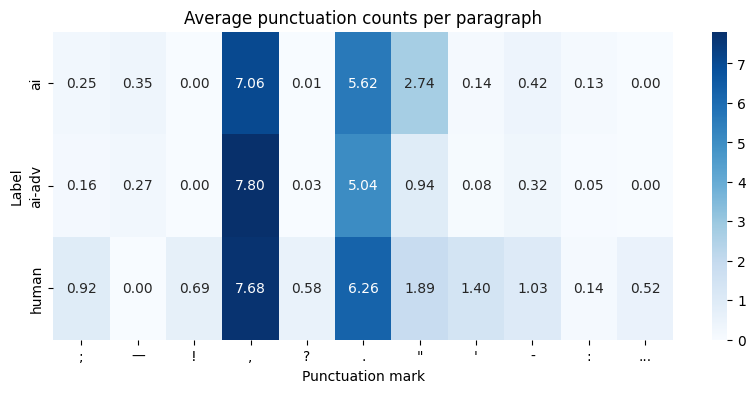

In [7]:
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

punctuation_marks = [';', '—', '!', ',', '?', '.', '"', "'", '-', ':', '...']
punc_counts = {}

for para_data in all_data:
    para_text = para_data['text']
    para_punc_counts = {}
    
    for mark in punctuation_marks:
        para_punc_counts[mark] = para_text.count(mark)
    
    para_data['punctuation'] = para_punc_counts

punc_rows = []
for para_data in all_data:
    punc = para_data.get("punctuation", {})
    if punc:
        row = {"label": para_data["label"]}
        row.update(punc)
        punc_rows.append(row)

punc_df = pd.DataFrame(punc_rows)
avg_punc = punc_df.groupby("label")[punctuation_marks].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(avg_punc, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Punctuation mark")
plt.ylabel("Label")
plt.title("Average punctuation counts per paragraph")
plt.show()

Readability Indices. Not doing this manually cause apparently counting syllables in a word is a PITA

In [8]:
import textstat

fk_this = []

for file, tag in files:
    with open(f"books/{file}", "r", encoding="utf-8") as f:
        print(f"Stats for {file}:")
        text = f.read()
        fk_grades = textstat.flesch_kincaid_grade(text)
        fk_this.append(fk_grades)
        fk = textstat.flesch_reading_ease(text)
        print(f"Flesch Reading Ease: {fk}", end=" | ")
        print(f"Flesch-Kincaid Grade Level: {fk_grades}")
        print()

for para_data in all_data:
    para_text = para_data["text"]
    if para_text:
        para_data["fk_grade"] = textstat.flesch_kincaid_grade(para_text)
        # para_data["fk_reading_ease"] = textstat.flesch_reading_ease(para_text)

fk_sums = {"ai": 0.0, "ai-adv": 0.0, "human": 0.0}
fk_counts = {"ai": 0, "ai-adv": 0, "human": 0}
for para in all_data:
    fk = para.get("fk_grade")
    label = para.get("label")
    if fk is not None and label in fk_sums:
        fk_sums[label] += fk
        fk_counts[label] += 1

for label in ["ai", "ai-adv", "human"]:
    if fk_counts[label] > 0:
        print(f"{label} - Avg FK Grade: {fk_sums[label] / fk_counts[label]:.2f}")
    else:
        print(f"{label} - Avg FK Grade: N/A")


Stats for crime_and_punishment.txt:
Flesch Reading Ease: 77.21684789644765 | Flesch-Kincaid Grade Level: 5.804694218233184

Stats for pride_and_prejudice.txt:
Flesch Reading Ease: 64.69409672338145 | Flesch-Kincaid Grade Level: 8.885497332158838

Stats for class2_crime_and_punishment.txt:
Flesch Reading Ease: 44.59663791830576 | Flesch-Kincaid Grade Level: 12.968137185547587

Stats for class2_pride_and_prejudice.txt:
Flesch Reading Ease: 32.512195522461894 | Flesch-Kincaid Grade Level: 15.211647001383614

Stats for class3_crime_and_punishment.txt:
Flesch Reading Ease: 54.66055032889197 | Flesch-Kincaid Grade Level: 12.547007718606089

Stats for class3_pride_and_prejudice.txt:
Flesch Reading Ease: 44.782453586568806 | Flesch-Kincaid Grade Level: 13.724719048072789

ai - Avg FK Grade: 14.04
ai-adv - Avg FK Grade: 13.25
human - Avg FK Grade: 8.87


In [9]:
import pickle
for i in range(len(all_data)):
    if all_data[i]['label'] == 'ai-adv':
        all_data[i]['label'] = 'ai'

pickle.dump(all_data, open("para_data.pkl", "wb"))